## Cryptocurrency Trader Behavior and Profitability Analysis Based on Market Sentiment

### 1. Introduction

This project analyzes the trading behavior and profitability of cryptocurrency traders and explores its relationship with overall market sentiment, as captured by the Fear & Greed Index. By examining a dataset of historical trades and corresponding sentiment data, we aim to identify patterns and correlations that can provide insights into how market sentiment might influence trading decisions and outcomes.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


In [101]:
sentiment_df = pd.read_csv("/content/fear_greed_index.csv")
trader_df  = pd.read_csv("/content/historical_data.csv", low_memory=False, on_bad_lines='skip')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [47]:
trader_df.info()
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122571 entries, 0 to 122570
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           122571 non-null  object 
 1   Coin              122571 non-null  object 
 2   Execution Price   122571 non-null  object 
 3   Size Tokens       122571 non-null  float64
 4   Size USD          122570 non-null  object 
 5   Side              122570 non-null  object 
 6   Timestamp IST     122570 non-null  object 
 7   Start Position    122570 non-null  float64
 8   Direction         122570 non-null  object 
 9   Closed PnL        122570 non-null  float64
 10  Transaction Hash  122569 non-null  object 
 11  Order ID          122569 non-null  float64
 12  Crossed           122569 non-null  object 
 13  Fee               122568 non-null  float64
 14  Trade ID          122567 non-null  float64
 15  Timestamp         122567 non-null  float64
dtypes: float64(7), objec

In [48]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.003055,1.050000e+15,1.730000e+12


# Using errors='coerce' will turn any parsing errors into NaT (Not a Time)

In [49]:
# Ensure numeric PnL and size
trader_df['Closed PnL'] = pd.to_numeric(trader_df['Closed PnL'], errors='coerce')
trader_df['Size USD'] = pd.to_numeric(trader_df['Size USD'], errors='coerce')
trader_df['Trade ID'] = pd.to_numeric(trader_df['Trade ID'], errors='coerce')
trader_df['Timestamp'] = trader_df['Timestamp'].astype(str).str.replace(r'[^\d.eE+-]', '', regex=True)
#trader_df['Timestamp'] = pd.to_datetime(trader_df['Timestamp'])
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
trader_df['date'] = trader_df['Timestamp IST'].dt.date
trader_df['date'] = pd.to_datetime(trader_df['date'])



sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
sentiment_df['timestamp_utc'] = pd.to_datetime(sentiment_df['timestamp'], unit='s', errors='coerce')

In [50]:

trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122571 entries, 0 to 122570
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           122571 non-null  object        
 1   Coin              122571 non-null  object        
 2   Execution Price   122571 non-null  object        
 3   Size Tokens       122571 non-null  float64       
 4   Size USD          122569 non-null  float64       
 5   Side              122570 non-null  object        
 6   Timestamp IST     122569 non-null  datetime64[ns]
 7   Start Position    122570 non-null  float64       
 8   Direction         122570 non-null  object        
 9   Closed PnL        122570 non-null  float64       
 10  Transaction Hash  122569 non-null  object        
 11  Order ID          122569 non-null  float64       
 12  Crossed           122569 non-null  object        
 13  Fee               122568 non-null  float64       
 14  Trad

In [51]:
# Convert numerical columns from object to numeric
numeric_cols_historical = ['Execution Price', 'Size Tokens', 'Size USD', 'Start Position', 'Closed PnL', 'Fee']

In [52]:
for col in numeric_cols_historical:
     trader_df[col] = pd.to_numeric(trader_df[col].astype(str).str.replace(',', ''), errors='coerce')

In [53]:
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122571 entries, 0 to 122570
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           122571 non-null  object        
 1   Coin              122571 non-null  object        
 2   Execution Price   122570 non-null  float64       
 3   Size Tokens       122571 non-null  float64       
 4   Size USD          122569 non-null  float64       
 5   Side              122570 non-null  object        
 6   Timestamp IST     122569 non-null  datetime64[ns]
 7   Start Position    122570 non-null  float64       
 8   Direction         122570 non-null  object        
 9   Closed PnL        122570 non-null  float64       
 10  Transaction Hash  122569 non-null  object        
 11  Order ID          122569 non-null  float64       
 12  Crossed           122569 non-null  object        
 13  Fee               122568 non-null  float64       
 14  Trad

In [54]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.345404,8.950000e+14,1730000000000.0,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.005600,4.430000e+14,1730000000000.0,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.050431,6.600000e+14,1730000000000.0,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.050043,1.080000e+15,1730000000000.0,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,TRUE,0.003055,1.050000e+15,1730000000000.0,2024-12-02


In [55]:
trader_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,date
count,1.225700e+05,1.225710e+05,1.225690e+05,122569,1.225700e+05,1.225700e+05,1.225690e+05,1.225680e+05,1.225670e+05,122569
mean,4.111947e+09,1.419821e+07,6.946494e+03,2025-02-23 23:20:44.181644544,-7.008026e+04,1.501233e+07,7.390788e+10,1.427779e+07,5.630474e+14,2025-02-23 10:33:51.254232320
min,1.000000e-05,0.000000e+00,0.000000e+00,2024-04-20 12:28:00,-1.397130e+07,-1.179901e+05,2.320870e-01,0.000000e+00,0.000000e+00,2024-04-20 00:00:00
25%,3.573200e+00,3.000000e+00,1.952400e+02,2025-01-14 03:39:00,-1.106007e+03,0.000000e+00,6.279441e+10,2.000100e-02,2.830000e+14,2025-01-14 00:00:00
50%,1.814000e+01,3.169000e+01,5.883500e+02,2025-03-06 20:06:00,2.464234e+01,0.000000e+00,7.762970e+10,1.004640e-01,5.630000e+14,2025-03-06 00:00:00
75%,1.358000e+02,1.904500e+02,2.071790e+03,2025-04-10 00:10:00,5.732850e+03,5.145075e+00,8.539710e+10,4.193840e-01,8.450000e+14,2025-04-10 00:00:00
max,5.040000e+14,1.740000e+12,3.921431e+06,2025-05-01 12:13:00,8.540364e+06,1.750000e+12,9.014245e+10,1.750000e+12,1.130000e+15,2025-05-01 00:00:00
std,1.439589e+12,4.969988e+09,4.661913e+04,NaN,7.753331e+05,5.005184e+09,1.281308e+10,4.998613e+09,3.248707e+14,NaN


In [56]:
trader_df.isnull()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122566,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
122567,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
122568,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
122569,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [57]:
sentiment_df.isnull()

,timestamp,value,classification,date,timestamp_utc
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
2639,False,False,False,False,False
2640,False,False,False,False,False
2641,False,False,False,False,False
2642,False,False,False,False,False


In [58]:
trader_df.isnull().sum()


,0
Account,0
Coin,0
Execution Price,1
Size Tokens,0
Size USD,2
Side,1
Timestamp IST,2
Start Position,1
Direction,1
Closed PnL,1


In [59]:
sentiment_df.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0
timestamp_utc,0


In [60]:
merged_df = pd.merge(trader_df, sentiment_df, on='date', how='left')

In [61]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122571 entries, 0 to 122570
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           122571 non-null  object        
 1   Coin              122571 non-null  object        
 2   Execution Price   122570 non-null  float64       
 3   Size Tokens       122571 non-null  float64       
 4   Size USD          122569 non-null  float64       
 5   Side              122570 non-null  object        
 6   Timestamp IST     122569 non-null  datetime64[ns]
 7   Start Position    122570 non-null  float64       
 8   Direction         122570 non-null  object        
 9   Closed PnL        122570 non-null  float64       
 10  Transaction Hash  122569 non-null  object        
 11  Order ID          122569 non-null  float64       
 12  Crossed           122569 non-null  object        
 13  Fee               122568 non-null  float64       
 14  Trad

In [62]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification,timestamp_utc
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,5.201771e+10,TRUE,0.345404,8.950000e+14,1730000000000.0,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02 05:30:00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,5.201771e+10,TRUE,0.005600,4.430000e+14,1730000000000.0,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02 05:30:00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,5.201771e+10,TRUE,0.050431,6.600000e+14,1730000000000.0,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02 05:30:00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,5.201771e+10,TRUE,0.050043,1.080000e+15,1730000000000.0,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02 05:30:00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,5.201771e+10,TRUE,0.003055,1.050000e+15,1730000000000.0,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02 05:30:00


In [63]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,date,timestamp,value,timestamp_utc
count,1.225700e+05,1.225710e+05,1.225690e+05,122569,1.225700e+05,1.225700e+05,1.225690e+05,1.225680e+05,1.225670e+05,122569,1.225630e+05,122563.000000,122563
mean,4.111947e+09,1.419821e+07,6.946494e+03,2025-02-23 23:20:44.181644544,-7.008026e+04,1.501233e+07,7.390788e+10,1.427779e+07,5.630474e+14,2025-02-23 10:33:51.254232320,1.740327e+09,51.108328,2025-02-23 16:12:20.675407872
min,1.000000e-05,0.000000e+00,0.000000e+00,2024-04-20 12:28:00,-1.397130e+07,-1.179901e+05,2.320870e-01,0.000000e+00,0.000000e+00,2024-04-20 00:00:00,1.713591e+09,10.000000,2024-04-20 05:30:00
25%,3.573200e+00,3.000000e+00,1.952400e+02,2025-01-14 03:39:00,-1.106007e+03,0.000000e+00,6.279441e+10,2.000100e-02,2.830000e+14,2025-01-14 00:00:00,1.736833e+09,32.000000,2025-01-14 05:30:00
50%,1.814000e+01,3.169000e+01,5.883500e+02,2025-03-06 20:06:00,2.464234e+01,0.000000e+00,7.762970e+10,1.004640e-01,5.630000e+14,2025-03-06 00:00:00,1.741239e+09,47.000000,2025-03-06 05:30:00
75%,1.358000e+02,1.904500e+02,2.071790e+03,2025-04-10 00:10:00,5.732850e+03,5.145075e+00,8.539710e+10,4.193840e-01,8.450000e+14,2025-04-10 00:00:00,1.744263e+09,72.000000,2025-04-10 05:30:00
max,5.040000e+14,1.740000e+12,3.921431e+06,2025-05-01 12:13:00,8.540364e+06,1.750000e+12,9.014245e+10,1.750000e+12,1.130000e+15,2025-05-01 00:00:00,1.746077e+09,94.000000,2025-05-01 05:30:00
std,1.439589e+12,4.969988e+09,4.661913e+04,NaN,7.753331e+05,5.005184e+09,1.281308e+10,4.998613e+09,3.248707e+14,NaN,4.380774e+06,21.608658,NaN


In [64]:
merged_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,1
Size Tokens,0
Size USD,2
Side,1
Timestamp IST,2
Start Position,1
Direction,1
Closed PnL,1


(-500.0, 500.0)

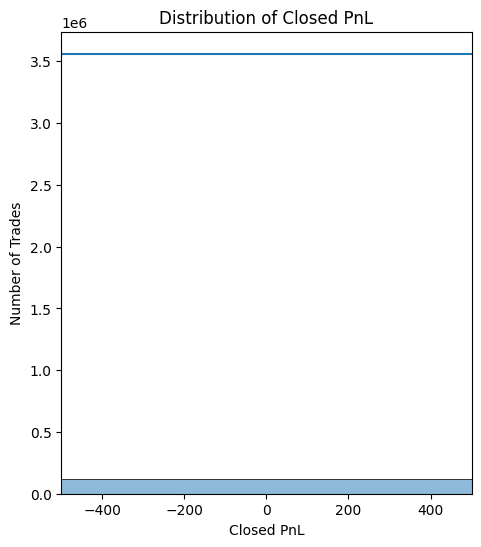

In [65]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)




sns.histplot(merged_df['Closed PnL'], bins=50,kde=True )
plt.title('Distribution of Closed PnL')
plt.xlabel('Closed PnL')
plt.ylabel('Number of Trades')
plt.xlim(-500, 500) # Limiting x-axis for better visualization of main distribution

In [66]:
# plt.subplot(1, 3, 2)

(0.0, 5000.0)

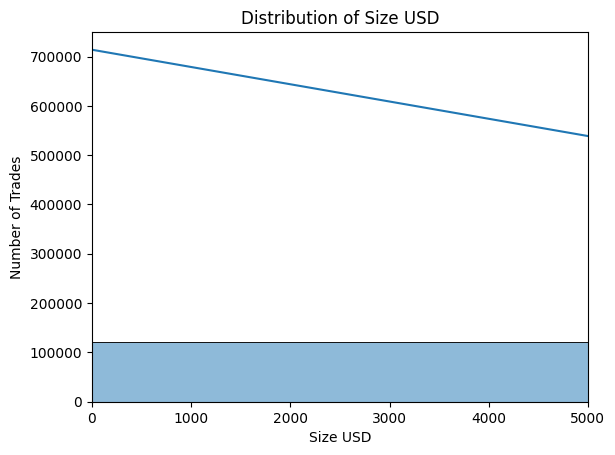

In [67]:

sns.histplot(merged_df['Size USD'], bins=50, kde=True)
plt.title('Distribution of Size USD')
plt.xlabel('Size USD')
plt.ylabel('Number of Trades')
plt.xlim(0, 5000) # Limiting x-axis for better visualization of common trade sizes

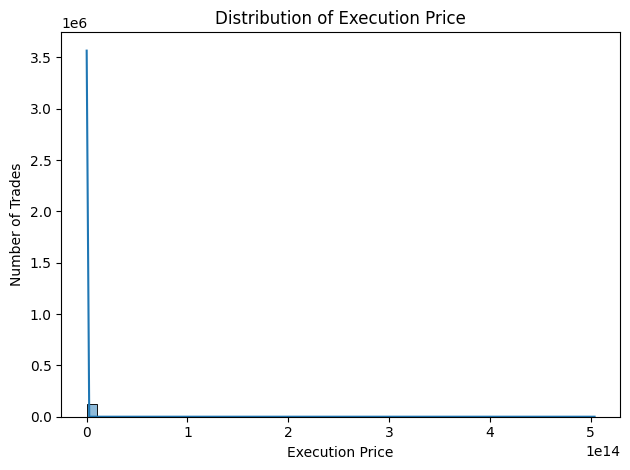

In [68]:
#plt.subplot(1, 3, 3)
sns.histplot(merged_df['Execution Price'], bins=50, kde=True)
plt.title('Distribution of Execution Price')
plt.xlabel('Execution Price')
plt.ylabel('Number of Trades')
plt.tight_layout()
plt.show()


/tmp/ipython-input-2130322734.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_df, x='Side', palette='viridis')


Text(0, 0.5, 'Number of Trades')

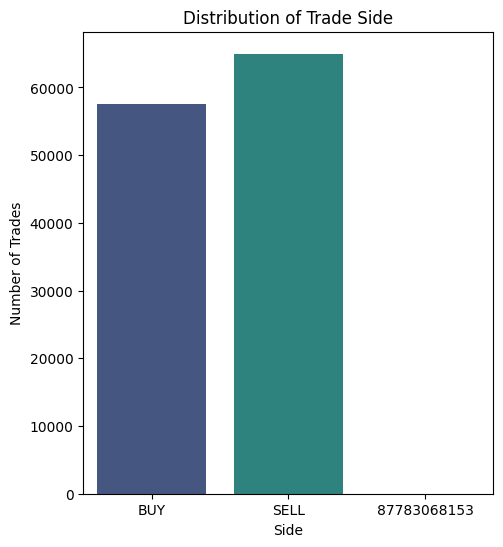

In [69]:
# --- 3. Distribution of Categorical Variables ---

plt.figure(figsize=(18, 6))



plt.subplot(1, 3, 1)
sns.countplot(data=merged_df, x='Side', palette='viridis')
plt.title('Distribution of Trade Side')
plt.xlabel('Side')
plt.ylabel('Number of Trades')

/tmp/ipython-input-1774777882.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_df, x='Direction', palette='cividis')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Buy'),
  Text(1, 0, 'Sell'),
  Text(2, 0, 'Open Long'),
  Text(3, 0, 'Close Long'),
  Text(4, 0, 'Spot Dust Conversion'),
  Text(5, 0, 'Open Short'),
  Text(6, 0, 'Close Short'),
  Text(7, 0, 'Long > Short'),
  Text(8, 0, 'Short > Long'),
  Text(9, 0, '9.74E+14'),
  Text(10, 0, 'Liquidated Isolated Short'),
  Text(11, 0, 'Close Short50e805e96b5e14b14fdba5a74'),
  Text(12, 0, 'Auto-Deleveraging'),
  Text(13, 0, 'Close'),
  Text(14, 0, 'Settlement')])

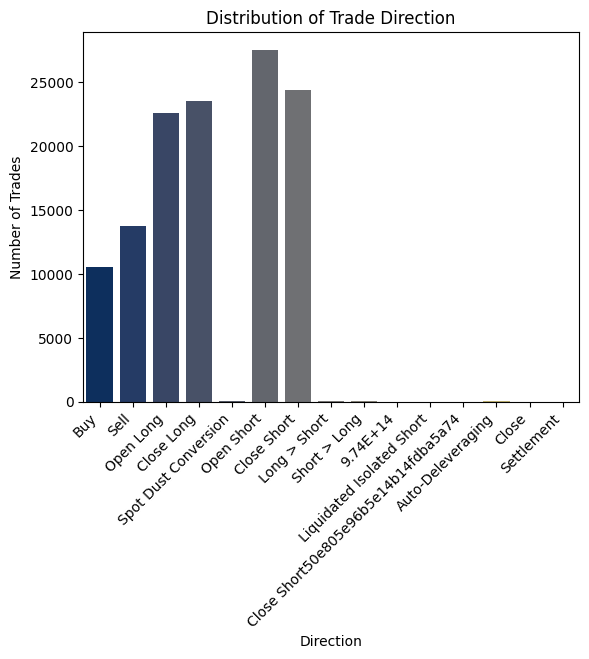

In [70]:
#plt.subplot(1, 3, 2)
sns.countplot(data=merged_df, x='Direction', palette='cividis')
plt.title('Distribution of Trade Direction')
plt.xlabel('Direction')
plt.ylabel('Number of Trades')
plt.xticks(rotation=45, ha='right')

/tmp/ipython-input-115702832.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_df_sentiment_present, x='classification', order=merged_df_sentiment_present['classification'].value_counts().index, palette='magma')


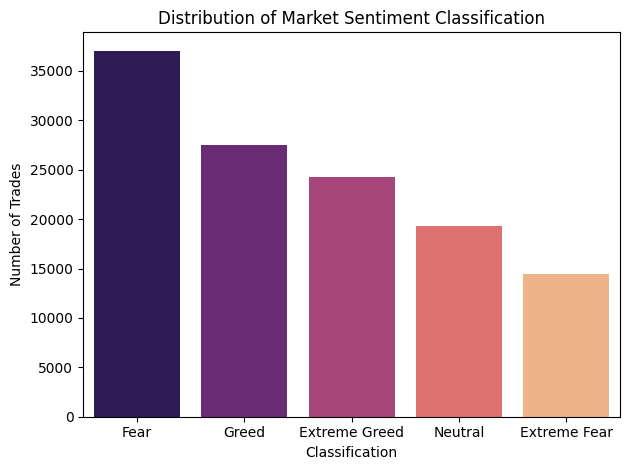

In [71]:
#plt.subplot(1, 3, 3)
# Handle potential NaN in 'classification' if there are missing sentiment values
# You can fill them with a placeholder like 'Unknown' or drop them for this specific plot
merged_df_sentiment_present = merged_df.dropna(subset=['classification'])
sns.countplot(data=merged_df_sentiment_present, x='classification', order=merged_df_sentiment_present['classification'].value_counts().index, palette='magma')
plt.title('Distribution of Market Sentiment Classification')
plt.xlabel('Classification')
plt.ylabel('Number of Trades')
plt.tight_layout()
plt.show()

In [72]:
# --- 4. Trader Profitability Analysis ---

print("\n4. Trader Profitability Analysis:")

# Total PnL
total_pnl = merged_df['Closed PnL'].sum()
print(f"Total Closed PnL across all trades: ${total_pnl:,.2f}")


4. Trader Profitability Analysis:
Total Closed PnL across all trades: $1,840,061,655,423.63


In [73]:
# Number of profitable/unprofitable/break-even trades
profitable_trades = merged_df[merged_df['Closed PnL'] > 0].shape[0]
unprofitable_trades = merged_df[merged_df['Closed PnL'] < 0].shape[0]
break_even_trades = merged_df[merged_df['Closed PnL'] == 0].shape[0]

print(f"Number of Profitable Trades: {profitable_trades} ({profitable_trades / len(merged_df) * 100:.2f}%)")
print(f"Number of Unprofitable Trades: {unprofitable_trades} ({unprofitable_trades / len(merged_df) * 100:.2f}%)")
print(f"Number of Break-Even Trades: {break_even_trades} ({break_even_trades / len(merged_df) * 100:.2f}%)")

Number of Profitable Trades: 48464 (39.54%)
Number of Unprofitable Trades: 13282 (10.84%)
Number of Break-Even Trades: 60824 (49.62%)


In [74]:
# PnL by Trade Side (Buy/Sell)
pnl_by_side = merged_df.groupby('Side')['Closed PnL'].agg(['sum', 'mean', 'count'])
print("\nTotal and Average PnL by Trade Side:")
print(pnl_by_side)


Total and Average PnL by Trade Side:
                      sum          mean  count
Side                                          
87783068153  1.750000e+12  1.750000e+12      1
BUY          9.005833e+10  1.563730e+06  57592
SELL         3.327826e+06  5.121545e+01  64977


In [75]:
# PnL by Trade Direction (Open/Close Long/Short)
pnl_by_direction = merged_df.groupby('Direction')['Closed PnL'].agg(['sum', 'mean', 'count'])
print("\nTotal and Average PnL by Trade Direction:")
print(pnl_by_direction)


Total and Average PnL by Trade Direction:
                                               sum          mean  count
Direction                                                              
9.74E+14                              1.750000e+12  1.750000e+12      1
Auto-Deleveraging                     5.747846e+04  7.184807e+03      8
Buy                                   0.000000e+00  0.000000e+00  10538
Close                                 1.435766e+01  1.435766e+01      1
Close Long                            1.957917e+06  8.324477e+01  23520
Close Short                           2.568873e+06  1.053464e+02  24385
Close Short50e805e96b5e14b14fdba5a74  9.005577e+10  9.005577e+10      1
Liquidated Isolated Short            -1.275291e+04 -1.275291e+04      1
Long > Short                          1.573900e+02  4.141842e+00     38
Open Long                             0.000000e+00  0.000000e+00  22621
Open Short                            0.000000e+00  0.000000e+00  27570
Sell                 

In [76]:
# Top/Bottom Accounts by PnL (Overall)
top_accounts = merged_df.groupby('Account')['Closed PnL'].sum().nlargest(10)
bottom_accounts = merged_df.groupby('Account')['Closed PnL'].sum().nsmallest(10)

print("\nTop 10 Profitable Accounts:")
print(top_accounts)
print("\nTop 10 Unprofitable Accounts:")
print(bottom_accounts)


Top 10 Profitable Accounts:
Account
51                                            1.750000e+12
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    9.005588e+10
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    3.288576e+05
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    2.205191e+05
Name: Closed PnL, dtype: float64

Top 10 Unprofitable Accounts:
Account
0x8170715b3b381dffb7062c0298972d4727a0a63b   -167621.124781
0x271b280974205ca63b716753467d5a371de622ab    -70436.191318
0x8477e447846c758f5a675856001ea72298f              0.000000
0x8477e447846c758f5a675856001ea72298fd9cb5      5893.883824
0x39cef799f8b69da1995852eea189df24eb5cae3c     14456.919336
0

In [77]:
# --- 5. Sentiment-Trader Behavior Relationship ---

print("\n5. Sentiment-Trader Behavior Relationship:")

# Average PnL by Sentiment Classification
pnl_by_sentiment = merged_df.groupby('classification')['Closed PnL'].agg(['mean', 'sum', 'count']).sort_values(by='mean', ascending=False)
print("\nAverage, Total PnL, and Trade Count by Market Sentiment:")
print(pnl_by_sentiment)


5. Sentiment-Trader Behavior Relationship:

Average, Total PnL, and Trade Count by Market Sentiment:
                        mean           sum  count
classification                                   
Greed           3.278256e+06  9.005698e+10  27471
Fear            6.704389e+01  2.484043e+06  37051
Extreme Greed   4.267781e+01  1.034894e+06  24249
Neutral         3.583845e+01  6.934741e+05  19350
Extreme Fear    2.916126e+01  4.211469e+05  14442


/tmp/ipython-input-1993745866.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment['mean'], palette='coolwarm')


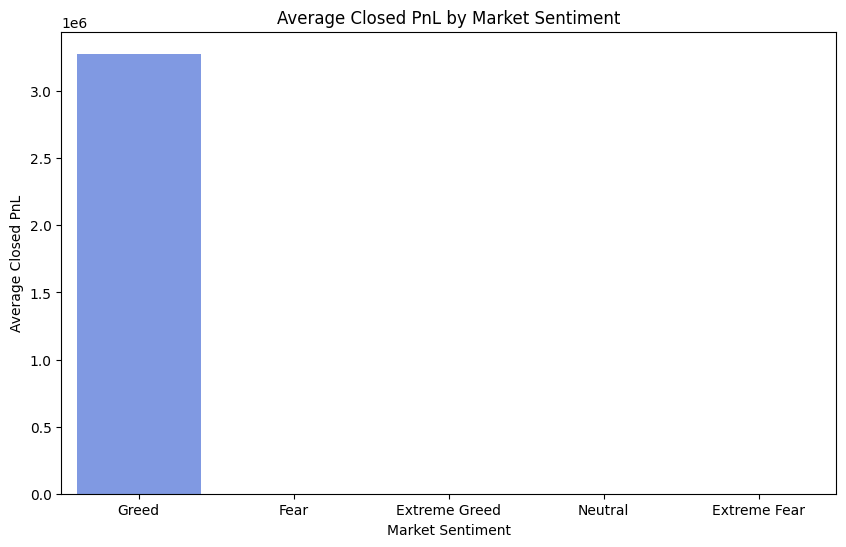

In [78]:
plt.figure(figsize=(10, 6))
sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment['mean'], palette='coolwarm')
plt.title('Average Closed PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.show()


Total and Average Trade Volume (Size USD) by Market Sentiment:
                         sum          mean  count
classification                                   
Fear            4.060593e+08  10959.470380  37051
Greed           1.882798e+08   6853.766975  27471
Neutral         1.263760e+08   6531.060683  19350
Extreme Fear    8.090127e+07   5601.804972  14442
Extreme Greed   4.971966e+07   2050.379696  24249


/tmp/ipython-input-1013648098.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=volume_by_sentiment.index, y=volume_by_sentiment['sum'], palette='plasma')


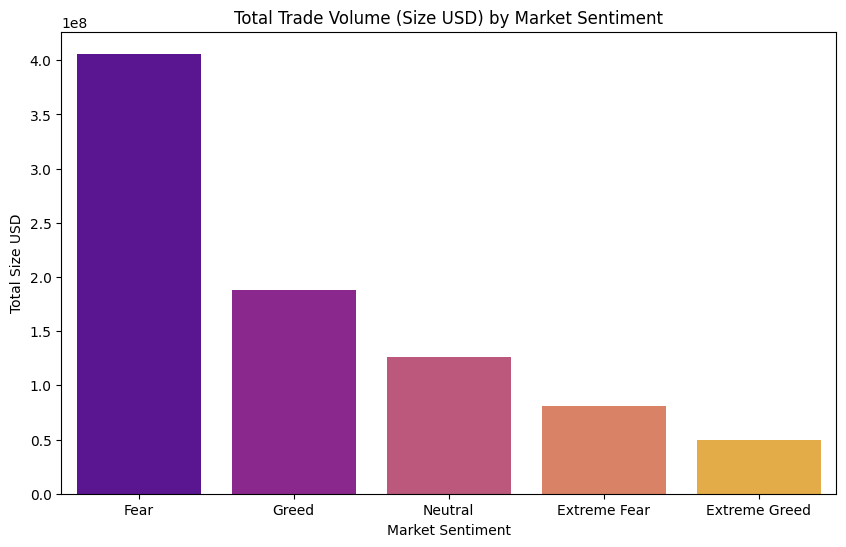

In [79]:
# Total Volume (Size USD) by Sentiment Classification
volume_by_sentiment = merged_df.groupby('classification')['Size USD'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)
print("\nTotal and Average Trade Volume (Size USD) by Market Sentiment:")
print(volume_by_sentiment)

plt.figure(figsize=(10, 6))
sns.barplot(x=volume_by_sentiment.index, y=volume_by_sentiment['sum'], palette='plasma')
plt.title('Total Trade Volume (Size USD) by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Total Size USD')
plt.show()

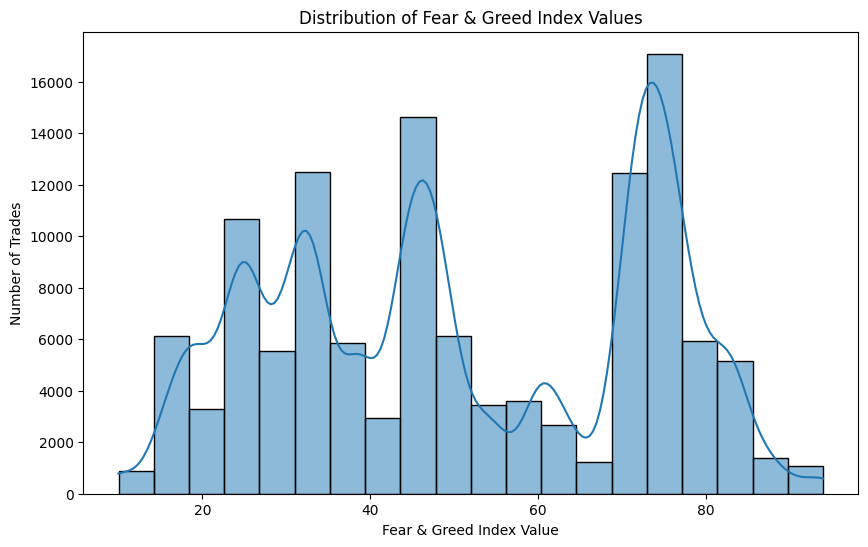

In [80]:
# Distribution of Sentiment Values
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['value'].dropna(), bins=20, kde=True)
plt.title('Distribution of Fear & Greed Index Values')
plt.xlabel('Fear & Greed Index Value')
plt.ylabel('Number of Trades')
plt.show()

In [81]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,date,timestamp,value,timestamp_utc
count,1.225700e+05,1.225710e+05,1.225690e+05,122569,1.225700e+05,1.225700e+05,1.225690e+05,1.225680e+05,1.225670e+05,122569,1.225630e+05,122563.000000,122563
mean,4.111947e+09,1.419821e+07,6.946494e+03,2025-02-23 23:20:44.181644544,-7.008026e+04,1.501233e+07,7.390788e+10,1.427779e+07,5.630474e+14,2025-02-23 10:33:51.254232320,1.740327e+09,51.108328,2025-02-23 16:12:20.675407872
min,1.000000e-05,0.000000e+00,0.000000e+00,2024-04-20 12:28:00,-1.397130e+07,-1.179901e+05,2.320870e-01,0.000000e+00,0.000000e+00,2024-04-20 00:00:00,1.713591e+09,10.000000,2024-04-20 05:30:00
25%,3.573200e+00,3.000000e+00,1.952400e+02,2025-01-14 03:39:00,-1.106007e+03,0.000000e+00,6.279441e+10,2.000100e-02,2.830000e+14,2025-01-14 00:00:00,1.736833e+09,32.000000,2025-01-14 05:30:00
50%,1.814000e+01,3.169000e+01,5.883500e+02,2025-03-06 20:06:00,2.464234e+01,0.000000e+00,7.762970e+10,1.004640e-01,5.630000e+14,2025-03-06 00:00:00,1.741239e+09,47.000000,2025-03-06 05:30:00
75%,1.358000e+02,1.904500e+02,2.071790e+03,2025-04-10 00:10:00,5.732850e+03,5.145075e+00,8.539710e+10,4.193840e-01,8.450000e+14,2025-04-10 00:00:00,1.744263e+09,72.000000,2025-04-10 05:30:00
max,5.040000e+14,1.740000e+12,3.921431e+06,2025-05-01 12:13:00,8.540364e+06,1.750000e+12,9.014245e+10,1.750000e+12,1.130000e+15,2025-05-01 00:00:00,1.746077e+09,94.000000,2025-05-01 05:30:00
std,1.439589e+12,4.969988e+09,4.661913e+04,NaN,7.753331e+05,5.005184e+09,1.281308e+10,4.998613e+09,3.248707e+14,NaN,4.380774e+06,21.608658,NaN


In [82]:
# PnL vs. Fear & Greed Index Value (Scatter plot)
# For better visualization, consider sampling if the dataset is too large or using aggregated data.
# Let's aggregate daily PnL and sentiment value for a clearer view.

daily_summary = merged_df.groupby('date').agg(
    Daily_PnL=('Closed PnL', 'sum'),
    Daily_Volume_USD=('Size USD', 'sum'),
    Avg_Sentiment_Value=('value', 'mean'),
    Most_Common_Sentiment=('classification', lambda x: x.mode()[0] if not x.mode().empty else np.nan)
).reset_index()

# Drop rows where Avg_Sentiment_Value is NaN (dates with no sentiment data)
daily_summary.dropna(subset=['Avg_Sentiment_Value'], inplace=True)

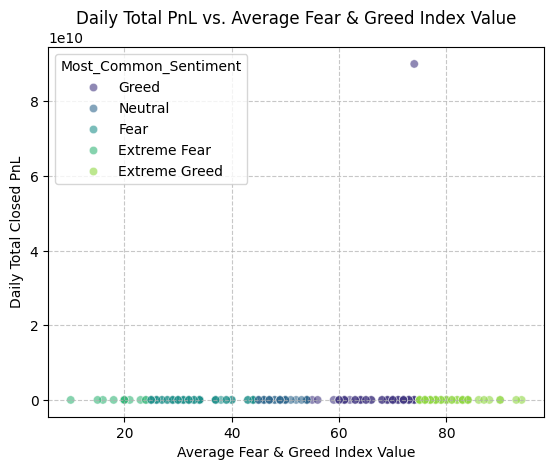

In [83]:
#plt.figure(figsize=(12, 7))
sns.scatterplot(data=daily_summary, x='Avg_Sentiment_Value', y='Daily_PnL', hue='Most_Common_Sentiment', palette='viridis', alpha=0.6)
plt.title('Daily Total PnL vs. Average Fear & Greed Index Value')
plt.xlabel('Average Fear & Greed Index Value')
plt.ylabel('Daily Total Closed PnL')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Text(0, 0.5, 'Daily Total Closed PnL')

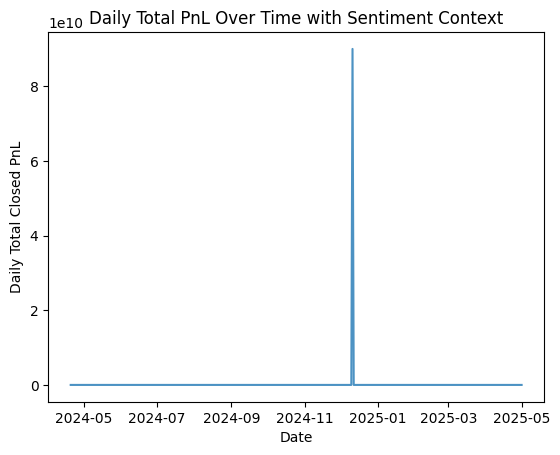

In [84]:
# PnL over time with sentiment overlay
#plt.figure(figsize=(15, 7))
plt.plot(daily_summary['date'], daily_summary['Daily_PnL'], label='Daily Total PnL', alpha=0.8)
plt.title('Daily Total PnL Over Time with Sentiment Context')
plt.xlabel('Date')
plt.ylabel('Daily Total Closed PnL')

In [85]:
# Correlation between numerical sentiment and PnL/Volume
correlation_pnl_sentiment = daily_summary['Daily_PnL'].corr(daily_summary['Avg_Sentiment_Value'])
correlation_volume_sentiment = daily_summary['Daily_Volume_USD'].corr(daily_summary['Avg_Sentiment_Value'])

print(f"\nCorrelation between Daily Total PnL and Average Sentiment Value: {correlation_pnl_sentiment:.4f}")
print(f"Correlation between Daily Total Volume (USD) and Average Sentiment Value: {correlation_volume_sentiment:.4f}")


Correlation between Daily Total PnL and Average Sentiment Value: 0.0588
Correlation between Daily Total Volume (USD) and Average Sentiment Value: -0.2460


Analyzing Buy/Sell Behavior vs. Market Sentiment


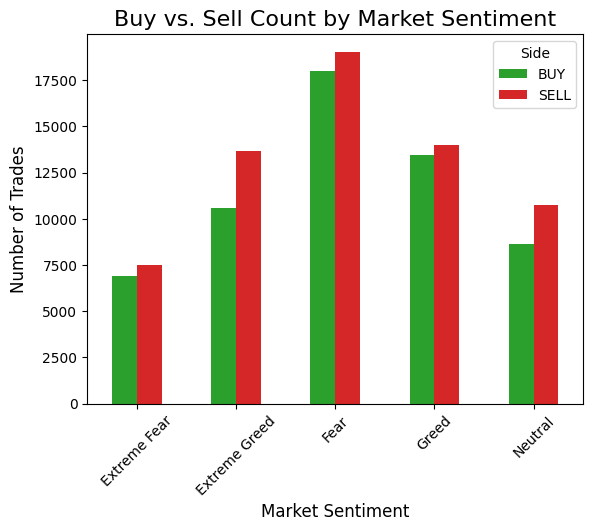

In [86]:

print("Analyzing Buy/Sell Behavior vs. Market Sentiment")
buy_sell_df = merged_df.groupby(['classification', 'Side']).size().unstack(fill_value=0)
buy_sell_df.plot(kind='bar', stacked=False, color=['#2ca02c', '#d62728']) # Green for BUY, Red for SELL
plt.title('Buy vs. Sell Count by Market Sentiment', fontsize=16)
plt.xlabel('Market Sentiment', fontsize=12)
plt.ylabel('Number of Trades', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Side')
plt.show()

In [87]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122571 entries, 0 to 122570
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           122571 non-null  object        
 1   Coin              122571 non-null  object        
 2   Execution Price   122570 non-null  float64       
 3   Size Tokens       122571 non-null  float64       
 4   Size USD          122569 non-null  float64       
 5   Side              122570 non-null  object        
 6   Timestamp IST     122569 non-null  datetime64[ns]
 7   Start Position    122570 non-null  float64       
 8   Direction         122570 non-null  object        
 9   Closed PnL        122570 non-null  float64       
 10  Transaction Hash  122569 non-null  object        
 11  Order ID          122569 non-null  float64       
 12  Crossed           122569 non-null  object        
 13  Fee               122568 non-null  float64       
 14  Trad

In [88]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,date,timestamp,value,timestamp_utc
count,1.225700e+05,1.225710e+05,1.225690e+05,122569,1.225700e+05,1.225700e+05,1.225690e+05,1.225680e+05,1.225670e+05,122569,1.225630e+05,122563.000000,122563
mean,4.111947e+09,1.419821e+07,6.946494e+03,2025-02-23 23:20:44.181644544,-7.008026e+04,1.501233e+07,7.390788e+10,1.427779e+07,5.630474e+14,2025-02-23 10:33:51.254232320,1.740327e+09,51.108328,2025-02-23 16:12:20.675407872
min,1.000000e-05,0.000000e+00,0.000000e+00,2024-04-20 12:28:00,-1.397130e+07,-1.179901e+05,2.320870e-01,0.000000e+00,0.000000e+00,2024-04-20 00:00:00,1.713591e+09,10.000000,2024-04-20 05:30:00
25%,3.573200e+00,3.000000e+00,1.952400e+02,2025-01-14 03:39:00,-1.106007e+03,0.000000e+00,6.279441e+10,2.000100e-02,2.830000e+14,2025-01-14 00:00:00,1.736833e+09,32.000000,2025-01-14 05:30:00
50%,1.814000e+01,3.169000e+01,5.883500e+02,2025-03-06 20:06:00,2.464234e+01,0.000000e+00,7.762970e+10,1.004640e-01,5.630000e+14,2025-03-06 00:00:00,1.741239e+09,47.000000,2025-03-06 05:30:00
75%,1.358000e+02,1.904500e+02,2.071790e+03,2025-04-10 00:10:00,5.732850e+03,5.145075e+00,8.539710e+10,4.193840e-01,8.450000e+14,2025-04-10 00:00:00,1.744263e+09,72.000000,2025-04-10 05:30:00
max,5.040000e+14,1.740000e+12,3.921431e+06,2025-05-01 12:13:00,8.540364e+06,1.750000e+12,9.014245e+10,1.750000e+12,1.130000e+15,2025-05-01 00:00:00,1.746077e+09,94.000000,2025-05-01 05:30:00
std,1.439589e+12,4.969988e+09,4.661913e+04,NaN,7.753331e+05,5.005184e+09,1.281308e+10,4.998613e+09,3.248707e+14,NaN,4.380774e+06,21.608658,NaN


In [89]:
merged_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,1
Size Tokens,0
Size USD,2
Side,1
Timestamp IST,2
Start Position,1
Direction,1
Closed PnL,1


In [90]:
merged_df.dropna(subset=['value', 'classification'], inplace=True)
merged_df['value'] = merged_df['value'].astype(int) # Ensure 'value' is integer for plotting

In [91]:
merged_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [92]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification,timestamp_utc
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,5.201771e+10,TRUE,0.345404,8.950000e+14,1730000000000.0,2024-12-02,1.733117e+09,80,Extreme Greed,2024-12-02 05:30:00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,5.201771e+10,TRUE,0.005600,4.430000e+14,1730000000000.0,2024-12-02,1.733117e+09,80,Extreme Greed,2024-12-02 05:30:00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,5.201771e+10,TRUE,0.050431,6.600000e+14,1730000000000.0,2024-12-02,1.733117e+09,80,Extreme Greed,2024-12-02 05:30:00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,5.201771e+10,TRUE,0.050043,1.080000e+15,1730000000000.0,2024-12-02,1.733117e+09,80,Extreme Greed,2024-12-02 05:30:00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,5.201771e+10,TRUE,0.003055,1.050000e+15,1730000000000.0,2024-12-02,1.733117e+09,80,Extreme Greed,2024-12-02 05:30:00


In [93]:
merged_df.isnull()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification,timestamp_utc
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122566,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
122567,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
122568,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
122569,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [94]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122563 entries, 0 to 122570
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           122563 non-null  object        
 1   Coin              122563 non-null  object        
 2   Execution Price   122563 non-null  float64       
 3   Size Tokens       122563 non-null  float64       
 4   Size USD          122563 non-null  float64       
 5   Side              122563 non-null  object        
 6   Timestamp IST     122563 non-null  datetime64[ns]
 7   Start Position    122563 non-null  float64       
 8   Direction         122563 non-null  object        
 9   Closed PnL        122563 non-null  float64       
 10  Transaction Hash  122563 non-null  object        
 11  Order ID          122563 non-null  float64       
 12  Crossed           122563 non-null  object        
 13  Fee               122562 non-null  float64       
 14  Trade ID 

Feature matrix shape: (122563, 13)
Features used: ['sentiment', 'sentiment_momentum', 'regime_duration', 'rolling_win_rate', 'size_relative', 'side_encoded', 'hour', 'day_of_week', 'regime_extreme_fear', 'regime_fear', 'regime_neutral', 'regime_greed', 'regime_extreme_greed']

CV RMSE (5-Fold TimeSeriesSplit): $469973551.46 ± $479448743.11

Test Set Performance:
RMSE: $47640830.31
MAE: $1456379.56
R²: -3111334321.803


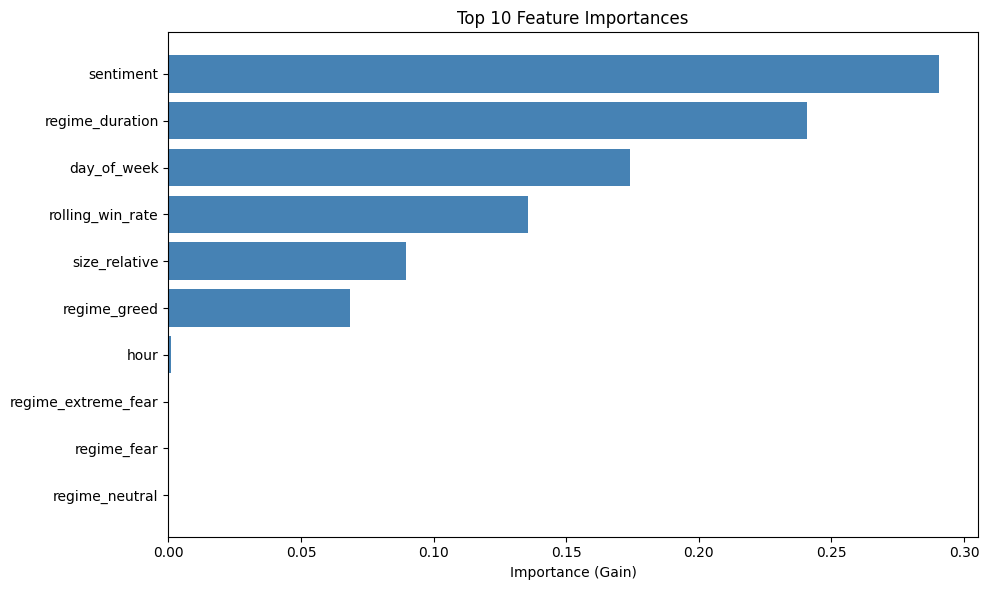

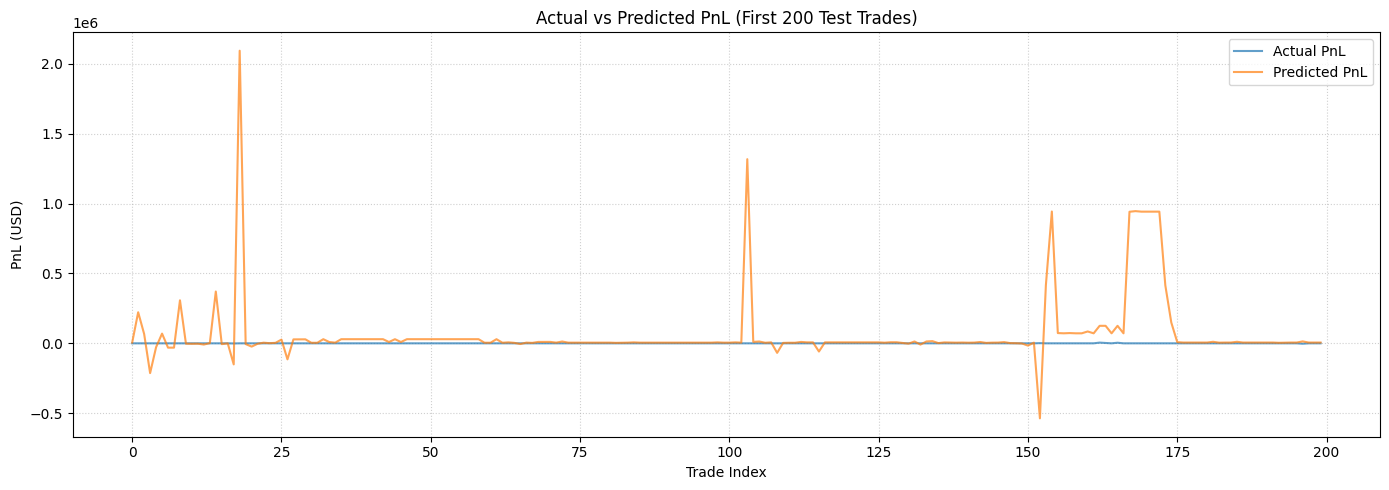


Regime-Specific Prediction Performance:
               actual_pnl  predicted_pnl  count
regime                                         
extreme_fear          NaN            NaN      0
fear            31.154411  656768.000000   9893
neutral          8.997175  -26473.058594   4368
greed          -24.427162  882968.187500  10252
extreme_greed         NaN            NaN      0

Model saved as 'sentiment_pnl_model.h5' using joblib serialization.


/tmp/ipython-input-1466448318.py:194: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_perf = df_test.groupby('regime').agg(


In [96]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import joblib # serialization

# =======================================================================
# STEP 1: DATA LOADING (ADJUSTED FOR YOUR MERGED_DF)
# =======================================================================

# 🛑 NO FAKE DATA GENERATION NEEDED.
# We assume 'merged_df' is already loaded and is your primary DataFrame.
df = merged_df.copy() # Use a copy to ensure original merged_df is untouched

# ----------------------------
# STEP 2: Preparing Features (Type Conversion & Cleaning)
# ----------------------------
# Note: Based on your df.info(), many columns are already in the right dtype,
# but we repeat these for safety and consistency.

# Correcting types using the column names from your merged_df
df['Timestamp IST'] = pd.to_datetime(df['Timestamp IST']) # Use Timestamp IST for consistency
df['Closed PnL'] = pd.to_numeric(df['Closed PnL'], errors='coerce')
df['value'] = pd.to_numeric(df['value'], errors='coerce') # Sentiment value column
df['Size USD'] = pd.to_numeric(df['Size USD'], errors='coerce')

# Drop NA rows where the sentiment data was slightly incomplete (6 rows)
df = df.dropna(subset=['Closed PnL', 'value', 'Timestamp IST', 'Account', 'Side', 'Size USD'])

# Sort by time (CRITICAL for sequential features)
df = df.sort_values('Timestamp IST').reset_index(drop=True)


# =======================================================================
# STEP 3: FEATURE ENGINEERING
# =======================================================================

# Raw sentiment
df['sentiment'] = df['value']

# Sentiment regime (one-hot)
df['regime'] = pd.cut(df['value'], bins=[0, 25, 45, 55, 75, 100],
                     labels=['extreme_fear', 'fear', 'neutral', 'greed', 'extreme_greed'])
regime_dummies = pd.get_dummies(df['regime'], prefix='regime')
df = pd.concat([df, regime_dummies], axis=1)

# Sentiment momentum (rate of change)
df['sentiment_momentum'] = df['value'].diff().fillna(0)

# Regime stability (duration)
df['regime_change'] = (df['regime'] != df['regime'].shift()).astype(int)
df['regime_duration'] = df.groupby((df['regime_change'] == 1).cumsum()).cumcount() + 1

# Trader behavioral proxies
# Win rate (rolling)
df['is_win'] = (df['Closed PnL'] > 0).astype(int)
df['rolling_win_rate'] = df.groupby('Account')['is_win'].transform(
    lambda x: x.rolling(window=20, min_periods=5).mean()
)

# Position size relative to trader average
df['avg_size_by_trader'] = df.groupby('Account')['Size USD'].transform('mean')
df['size_relative'] = df['Size USD'] / (df['avg_size_by_trader'] + 1e-8)

# Side encoding
df['side_encoded'] = df['Side'].map({'Buy': 1, 'Sell': -1}).fillna(0)

# Temporal features (Using 'Timestamp IST' column)
df['hour'] = df['Timestamp IST'].dt.hour
df['day_of_week'] = df['Timestamp IST'].dt.dayofweek

# Target Variable (Y): we predict Closed PnL
y = df['Closed PnL'].copy()


# ----------------------------
# STEP 4: Build Feature Matrix (X)
# ----------------------------
feature_cols = [
    'sentiment',
    'sentiment_momentum',
    'regime_duration',
    'rolling_win_rate',
    'size_relative',
    'side_encoded',
    'hour',
    'day_of_week'
] + list(regime_dummies.columns) # Add all one-hot encoded regime columns

# X = df[feature_cols].copy(): This creates the final matrix of independent variables (X)
X = df[feature_cols].copy()

# Imputation and Verification
X = X.fillna(0) # safe fill for any remaining NaNs (usually from min_periods in rolling calcs)

print(f"Feature matrix shape: {X.shape}")
print(f"Features used: {list(X.columns)}")


# ----------------------------
# Time-Series Safe Train/Test Split
# ----------------------------
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


# ----------------------------
# Scale features (optional for XGBoost, but good practice)
# ----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =======================================================================
# STEP 5 & 6: XGBoost Model Training and Evaluation
# =======================================================================

# XGBoost with conservative params to avoid overfitting
model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)


# Time-Series Cross-Validation (on scaled training data)
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(model, X_train_scaled, y_train,
                            cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
cv_rmse = np.sqrt(-cv_scores)
print(f"\nCV RMSE (5-Fold TimeSeriesSplit): ${cv_rmse.mean():.2f} ± ${cv_rmse.std():.2f}")


# Train Model & Predict
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nTest Set Performance:")
print(f"RMSE: ${np.sqrt(mse):.2f}")
print(f"MAE: ${mae:.2f}")
print(f"R²: {r2:.3f}")


# =======================================================================
# STEP 7-10: Interpretation and Saving
# =======================================================================

# Feature importance (Visualized)
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'][:10], importance['importance'][:10], color='steelblue')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance (Gain)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Prediction vs Actual (Time Series Plot)
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:200], label='Actual PnL', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted PnL', alpha=0.7)
plt.title('Actual vs Predicted PnL (First 200 Test Trades)')
plt.xlabel('Trade Index')
plt.ylabel('PnL (USD)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# Regime-Specific Performance
df_test = df.iloc[split_idx:].copy()
df_test['PnL_pred'] = y_pred
regime_perf = df_test.groupby('regime').agg(
    actual_pnl=('Closed PnL', 'mean'),
    predicted_pnl=('PnL_pred', 'mean'),
    count=('Closed PnL', 'count')
)
print("\nRegime-Specific Prediction Performance:")


print(regime_perf)


# Save Model
joblib.dump(model, 'sentiment_pnl_model.h5')
print("\nModel saved as 'sentiment_pnl_model.h5' using joblib serialization.")